# Решение задачи кластеризации

Импорт необходимых библиотек

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering

Генерация искусственных данных для примера

In [61]:
X, y = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=1.2, random_state=42)
X = StandardScaler().fit_transform(X)

### 1. Метод локтя для KMeans (подбор количества кластеров)

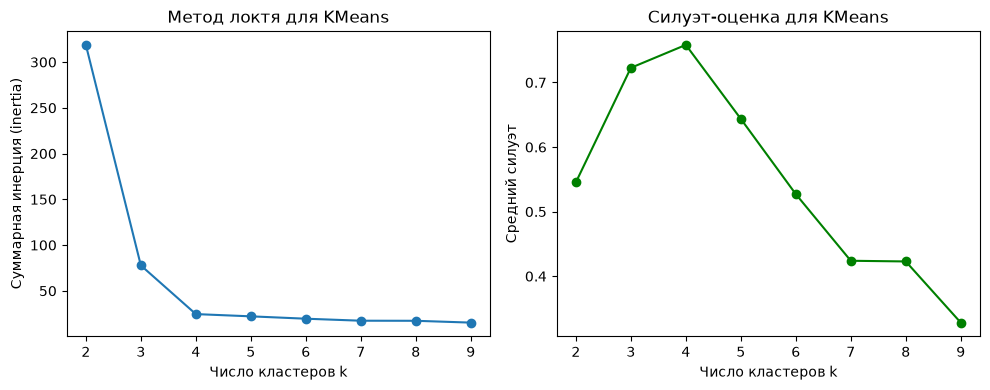

Оптимальное число кластеров по максимальной силуэт-оценке: 4


In [62]:
inertia = []
silhouette_scores = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Суммарная инерция (inertia)')
plt.title('Метод локтя для KMeans')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.xlabel('Число кластеров k')
plt.ylabel('Средний силуэт')
plt.title('Силуэт-оценка для KMeans')
plt.tight_layout()
plt.show()

# Выбор оптимального количества кластеров (обычно ищут "локтевой сгиб" на графике локтя)
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Оптимальное число кластеров по максимальной силуэт-оценке: {optimal_k}')

### 2. Кластеризация KMeans c оптимальным k

In [63]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
print('Средний силуэт KMeans:', silhouette_score(X, labels_kmeans))

Средний силуэт KMeans: 0.7582458926237312


In [64]:
labels_kmeans

array([3, 3, 0, 1, 3, 1, 2, 1, 0, 2, 0, 2, 0, 0, 3, 0, 3, 2, 0, 0, 2, 0,
       1, 3, 0, 3, 3, 1, 1, 2, 0, 2, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 3, 1,
       0, 0, 3, 2, 3, 2, 1, 3, 1, 0, 1, 2, 3, 2, 2, 0, 3, 2, 2, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 3, 2, 0, 3, 1, 1, 0, 1, 0, 0, 3, 0, 1, 3, 3, 2,
       2, 2, 3, 0, 3, 0, 0, 3, 1, 0, 3, 3, 2, 2, 2, 0, 0, 0, 0, 0, 1, 3,
       2, 0, 0, 0, 0, 2, 3, 1, 3, 1, 1, 1, 0, 3, 1, 3, 3, 0, 3, 1, 2, 0,
       0, 0, 0, 2, 2, 3, 0, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 3, 2, 1,
       0, 2, 1, 3, 3, 2, 0, 3, 1, 3, 2, 3, 1, 0, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 2, 1, 3, 0, 3, 2, 2, 3, 1, 0, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2,
       2, 3, 0, 0, 1, 2, 0, 1, 1, 3, 1, 0, 0, 1, 1, 2, 3, 1, 3, 3, 0, 3,
       3, 1, 3, 1, 2, 2, 3, 3, 2, 2, 2, 3, 0, 1, 2, 1, 3, 2, 3, 3, 3, 1,
       1, 2, 3, 1, 1, 1, 3, 1, 3, 1, 3, 2, 1, 3, 2, 0, 3, 0, 2, 0, 3, 0,
       1, 2, 1, 2, 2, 0, 0, 1, 2, 2, 3, 3, 1, 0, 0, 2, 2, 2, 2, 1, 3, 2,
       1, 2, 2, 1, 0, 1, 2, 0, 3, 0, 2, 0, 3, 3], d

### 3. Иерархическая кластеризация (агломеративная)

In [65]:

hier = AgglomerativeClustering(n_clusters=optimal_k)
labels_hier = hier.fit_predict(X)
print('Средний силуэт AgglomerativeClustering:', silhouette_score(X, labels_hier))

Средний силуэт AgglomerativeClustering: 0.7582458926237312


In [66]:
labels_hier

array([2, 2, 3, 1, 2, 1, 0, 1, 3, 0, 3, 0, 3, 3, 2, 3, 2, 0, 3, 3, 0, 3,
       1, 2, 3, 2, 2, 1, 1, 0, 3, 0, 2, 0, 2, 3, 2, 1, 2, 1, 0, 3, 2, 1,
       3, 3, 2, 0, 2, 0, 1, 2, 1, 3, 1, 0, 2, 0, 0, 3, 2, 0, 0, 3, 1, 1,
       1, 1, 1, 3, 1, 1, 2, 0, 3, 2, 1, 1, 3, 1, 3, 3, 2, 3, 1, 2, 2, 0,
       0, 0, 2, 3, 2, 3, 3, 2, 1, 3, 2, 2, 0, 0, 0, 3, 3, 3, 3, 3, 1, 2,
       0, 3, 3, 3, 3, 0, 2, 1, 2, 1, 1, 1, 3, 2, 1, 2, 2, 3, 2, 1, 0, 3,
       3, 3, 3, 0, 0, 2, 3, 1, 3, 0, 1, 3, 0, 0, 0, 0, 1, 3, 3, 2, 0, 1,
       3, 0, 1, 2, 2, 0, 3, 2, 1, 2, 0, 2, 1, 3, 3, 3, 3, 3, 1, 0, 0, 1,
       1, 0, 0, 1, 2, 3, 2, 0, 0, 2, 1, 3, 0, 0, 1, 1, 1, 2, 0, 1, 1, 0,
       0, 2, 3, 3, 1, 0, 3, 1, 1, 2, 1, 3, 3, 1, 1, 0, 2, 1, 2, 2, 3, 2,
       2, 1, 2, 1, 0, 0, 2, 2, 0, 0, 0, 2, 3, 1, 0, 1, 2, 0, 2, 2, 2, 1,
       1, 0, 2, 1, 1, 1, 2, 1, 2, 1, 2, 0, 1, 2, 0, 3, 2, 3, 0, 3, 2, 3,
       1, 0, 1, 0, 0, 3, 3, 1, 0, 0, 2, 2, 1, 3, 3, 0, 0, 0, 0, 1, 2, 0,
       1, 0, 0, 1, 3, 1, 0, 3, 2, 3, 0, 3, 2, 2])

### 4. Визуализация результатов

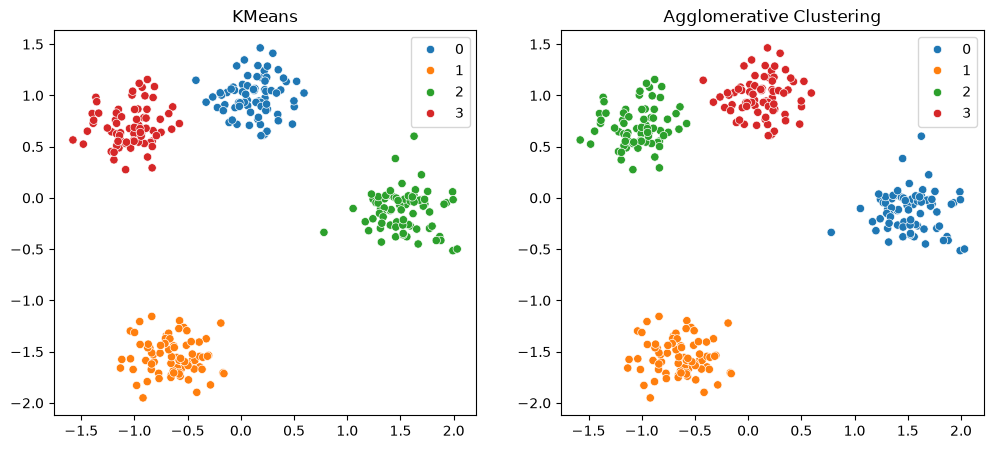

In [67]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels_kmeans, palette='tab10')
plt.title('KMeans')
plt.subplot(1,2,2)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels_hier, palette='tab10')
plt.title('Agglomerative Clustering')
plt.show()

### 5. Дендрограмма для иерархической кластеризации (Agglomerative Clustering)

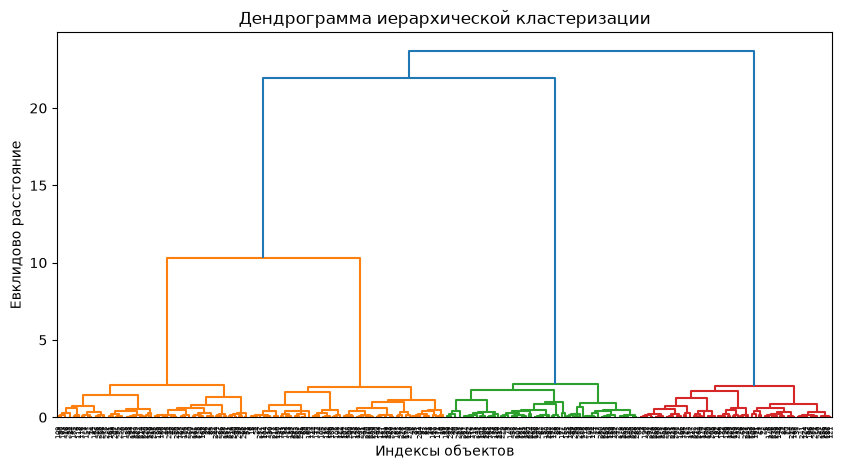

In [68]:
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 5))
linked = sch.linkage(X, method='ward')
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Индексы объектов')
plt.ylabel('Евклидово расстояние')
plt.show()

# Кластеризация на примере датасета Wine

**Wine dataset** из `sklearn` — это реальный, классический набор данных для задач в машинном обучении, особенно для классификации и кластеризации.

Источник: Исходные данные получены из исследований по химии вина *(UCI Machine Learning Repository)*.
## Описание:
Объекты: 178 образцов вина.

Признаки: 13 числовых признаков, характеризующих химический состав каждого вина:

1. Alcohol (алкоголь)

2. Malic acid (яблочная кислота)

3. Ash (зольность)

4. Alcalinity of ash (щелочность золы)

5. Magnesium (магний)

6. Total phenols (общие фенолы)

7. Flavanoids (флаваноиды)

8. Nonflavanoid phenols (нефлаваноидные фенолы)

9. Proanthocyanins (проантоцианидины)

10. Color intensity (интенсивность цвета)

11. Hue (оттенок)

12. OD280/OD315 of diluted wines (показатель OD)

13. Proline (пролин)

Классы: 3 типа вин (класс — сорт винограда, из которого сделано вино):

* Класс 0: сорта Barolo

* Класс 1: сорта Grignolino

* Класс 2: сорта Barbera

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


### 1. Загрузка датасета Wine, используем только два признака: alcohol (0), malic_acid (1)

In [70]:
wine = datasets.load_wine()
X = wine.data[:, [0, 1]]  # alcohol, malic_acid
# X = wine.data
# Масштабирование (стандартизация данных)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2. Метод локтя и силуэт для KMeans

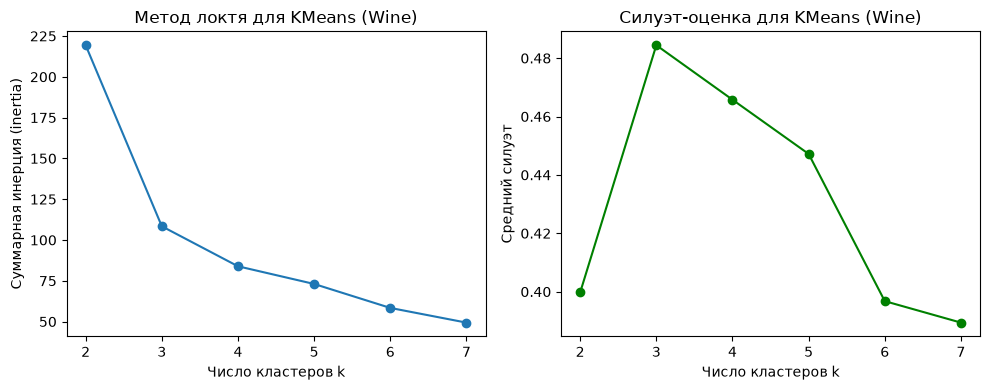

Оптимальное число кластеров по максимальной силуэт-оценке: 3


In [71]:
inertia = []
silhouette_scores = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Число кластеров k')
plt.ylabel('Суммарная инерция (inertia)')
plt.title('Метод локтя для KMeans (Wine)')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='green')
plt.xlabel('Число кластеров k')
plt.ylabel('Средний силуэт')
plt.title('Силуэт-оценка для KMeans (Wine)')
plt.tight_layout()
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Оптимальное число кластеров по максимальной силуэт-оценке: {optimal_k}')

### 3. Кластеризация KMeans с оптимальным k

In [72]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
print('Средний силуэт KMeans:', silhouette_score(X_scaled, labels_kmeans))

Средний силуэт KMeans: 0.484429111589854


In [73]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [74]:
labels_kmeans

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1,
       2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0, 0, 2, 1, 1, 1,
       2, 1], dtype=int32)

### 4. Agglomerative Clustering с оптимальным k

In [75]:
hier = AgglomerativeClustering(n_clusters=optimal_k)
labels_hier = hier.fit_predict(X_scaled)
print('Средний силуэт AgglomerativeClustering:', silhouette_score(X_scaled, labels_hier))

Средний силуэт AgglomerativeClustering: 0.4555820726259587


In [76]:
labels_hier

array([1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2,
       0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0])

### 5. Визуализация кластеров (реальные признаки)

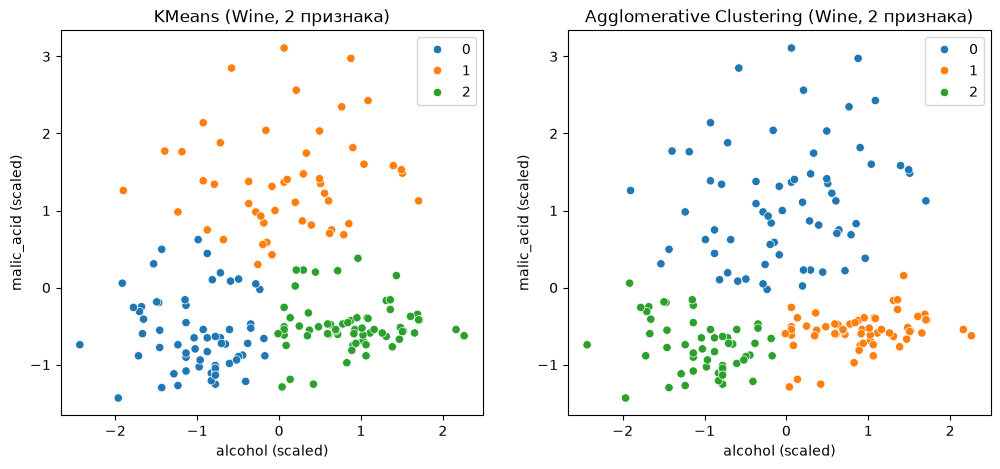

In [77]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels_kmeans, palette='tab10')
plt.xlabel('alcohol (scaled)')
plt.ylabel('malic_acid (scaled)')
plt.title('KMeans (Wine, 2 признака)')
plt.subplot(1,2,2)
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels_hier, palette='tab10')
plt.xlabel('alcohol (scaled)')
plt.ylabel('malic_acid (scaled)')
plt.title('Agglomerative Clustering (Wine, 2 признака)')
plt.show()


### 6. Дендрограмма

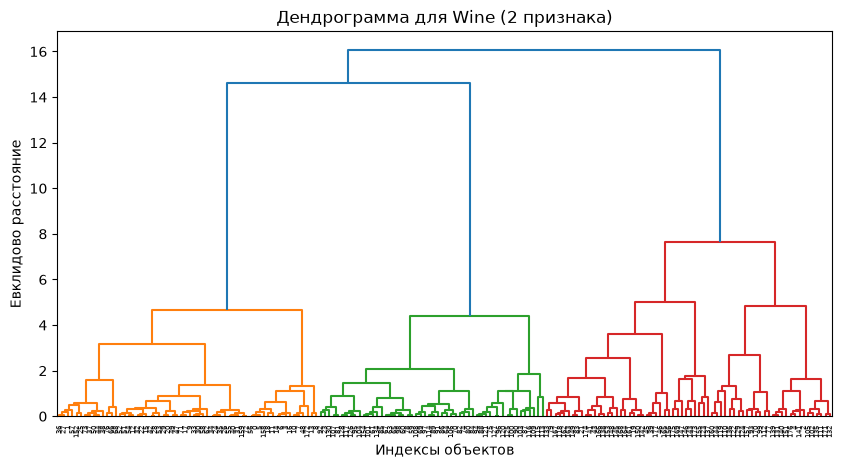

In [78]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Дендрограмма для Wine (2 признака)')
plt.xlabel('Индексы объектов')
plt.ylabel('Евклидово расстояние')
plt.show()